# COMP662 - Tutorial 4
# Diffusion Models: DDPM, DDIM, and Score Matching

Lincoln University, Department of Computing.

Generative AI course. This tutorial goes with the *Diffusion Models* lecture.

---

### What you will learn
By the end of this tutorial you should be able to:
1. Explain the **forward (noising)** and **reverse (denoising)** processes of a diffusion model.
2. Read a **noise schedule** and understand why adding many small Gaussians is itself one Gaussian (the closed-form shortcut).
3. Sample from a trained **DDPM** (stochastic, many steps).
4. Sample from a **DDIM** (deterministic, few steps) using the **same trained network**, and compare the two.
5. See how the number of sampling **steps** trades off speed against quality (fuzziness).
6. Understand what a **score** is, visualise it as a **vector field**, and sample it with two
   discretised solvers, a stochastic **SDE** (Euler-Maruyama) and a deterministic **PF-ODE** (Euler).
7. (Part 2, unguided exercise) Study the speed/quality trade-off, write a **stochastic eta-DDIM** sampler, and test whether the model **memorises** its training data.

### How this tutorial is structured
Part 1 is a guided walk-through (about 1.5 hours): read each explanation, then run the cell under it.
The heavy models are **pre-trained for you** (training a diffusion model from scratch is slow), so most
cells just **load** a saved model and let you play with it. Part 2 is an **unguided exercise** (about 60 to
90 minutes) with hints but no full solution.

### A note on running this
Everything here runs in **small mode** in a few minutes on a laptop (CPU or Apple GPU) or a free
Kaggle / Colab GPU. Two toggles in Section 0 control the heavy parts:

- **Data** is generated inside the notebook by default (procedural terrain tiles, no download). A switch
  lets you use the real **EuroSAT** satellite dataset instead (it downloads itself the first time).
- **Models** are loaded from the `models/` folder if present. If a weight file is missing, the notebook
  trains it on the spot, so a fresh run never gets stuck.

If you want to run this on a free GPU, Tutorial 3 has the step-by-step guide for turning on a Kaggle or
Colab T4. The setup cell below then picks that GPU up automatically.

---
# Part 1 - Guided walk-through (about 1.5 hours)

## Section 0. Setup and switches
Run this first. It imports libraries, picks the fastest device it can find, and sets a few switches.

In [1]:
import os, math, time                       # stdlib: paths, maths, timing
import numpy as np                          # arrays
import torch                                # PyTorch core
import torch.nn as nn                       # layers
import torch.nn.functional as F             # functional ops (conv, interpolate, ...)
import matplotlib.pyplot as plt             # 2D plotting
try:
    import plotly.graph_objects as go       # optional interactive 3D
    HAVE_PLOTLY = True
except Exception:
    HAVE_PLOTLY = False
print("PyTorch", torch.__version__, "| Plotly", "yes" if HAVE_PLOTLY else "no")

PyTorch 2.8.0 | Plotly yes


In [2]:
# ---- Switches (all in one place) ----------------------------------------
PREFER   = "auto"     # "auto" picks CUDA, else Apple MPS, else CPU. Force with "cuda"/"mps"/"cpu".
BIG      = False      # False = small + fast (laptop). True = more data + longer training (GPU server).
USE_EUROSAT = False   # False = procedural terrain tiles. True = real EuroSAT (auto-downloads once).
TRAIN_FROM_SCRATCH = False  # False = load models/*.pt (shipped weights). True = train here and save. Missing file -> trains anyway.
MODELS_DIR = "models"       # where trained weights live

# Real EuroSAT settings (only used when USE_EUROSAT = True)
EUROSAT_ROOT    = "data/eurosat/2750"                 # folder of per-class subfolders
EUROSAT_CLASSES = ["Forest", "Residential", "River"]  # three classes -> grayscale tiles

# ---- Sizes and diffusion length (scale a little with BIG) ---------------
IMG   = 32                       # tile size (square, grayscale)
T     = 200                      # number of diffusion steps in the forward process
N_PER_CLASS = 500 if BIG else 300   # terrain tiles per class
EPOCHS_UNET = 120 if BIG else 60    # image-diffusion (DDPM) training epochs
EPOCHS_SCORE = 600 if BIG else 400  # 2D score-net training epochs
BATCH = 128                      # mini-batch size
os.makedirs(MODELS_DIR, exist_ok=True)   # make sure the weights folder exists

### Picking the hardware
This chooses CUDA (Kaggle/Colab/servers), then Apple MPS (Mac), then CPU. Diffusion sampling is the
slowest part, so a GPU helps, but small mode is fine on CPU too.

In [3]:
def pick_device(prefer="auto"):
    # Return the best available torch.device given the PREFER switch.
    has_cuda = torch.cuda.is_available()
    has_mps  = hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
    if prefer == "cuda" and has_cuda: return torch.device("cuda")
    if prefer == "mps"  and has_mps:  return torch.device("mps")
    if prefer == "cpu":               return torch.device("cpu")
    if has_cuda: return torch.device("cuda")     # auto order: CUDA -> MPS -> CPU
    if has_mps:  return torch.device("mps")
    return torch.device("cpu")

device = pick_device(PREFER)                     # the device we will train / sample on
print("Using device:", device)
print(f"BIG={BIG}  IMG={IMG}  T={T}  tiles/class={N_PER_CLASS}  USE_EUROSAT={USE_EUROSAT}")

def save_model(m, name):                         # save weights into MODELS_DIR
    torch.save(m.state_dict(), os.path.join(MODELS_DIR, name))
    print("saved", os.path.join(MODELS_DIR, name))

def load_model(m, name):                         # load weights (map to our device)
    m.load_state_dict(torch.load(os.path.join(MODELS_DIR, name), map_location=device))
    print("loaded", os.path.join(MODELS_DIR, name)); return m

Using device: mps
BIG=False  IMG=32  T=200  tiles/class=300  USE_EUROSAT=False


## Section 1. What is a diffusion model?

### Why another generative model?
You have already met two. **VAEs** train stably but tend to produce blurry samples. **GANs** produce
sharp samples but train through an adversarial game that can collapse or refuse to converge. The
obvious question is whether we can have both: stable training *and* sharp output.

Diffusion models get there by changing the shape of the problem. Instead of asking one network to
produce a finished image in a single forward pass, which is hard, they **decompose generation into
many easy steps**: at each step the network only has to predict a *small amount of noise*. Nothing is
adversarial, so there is no minimax game to destabilise, and because the model fits the whole data
distribution rather than competing against a discriminator, **every mode contributes to learning**
instead of a few modes dominating.

That is the trade being made: many cheap steps instead of one hard one. It buys stability and sample
quality, and it costs generation speed, which is the problem DDIM (Section 5) exists to fix.

### The two halves
A diffusion model learns to **create images by removing noise**. The idea comes in two halves:

- **Forward process (fixed, no learning).** Start with a real image and add a little Gaussian noise,
  again and again, for `T` steps. After enough steps the image is pure noise.
- **Reverse process (learned).** Train a network to undo one step of noising. To generate a brand-new
  image, start from pure noise and run the learned step `T` times.

This tutorial covers three closely related members of the family:

| Model | Idea | What we do with it |
|---|---|---|
| **DDPM** | denoise step by step, stochastically | train it, then sample (many steps) |
| **DDIM** | same trained network, deterministic sampler | sample with **far fewer** steps |
| **Score matching** | learn the gradient of log-density (the *score*) | visualise it, sample with an SDE or PF-ODE solver |

The key practical message: **DDIM reuses the DDPM network**; it is a different way of *sampling*, not a
different model. Score matching is a different lens on the same maths: the network's noise prediction
**is** a scaled score, so DDPM, DDIM, and score-based sampling are one underlying idea viewed at different
levels of abstraction.

## Section 2. A small image dataset (built here, no download)

Diffusion is best understood by **watching** it, so we use small **32x32 grayscale terrain tiles** made
inside the notebook. Three land types, each with a different look:

- **mountains** - rough, high-frequency ridges.
- **plains** - smooth, gentle variation.
- **coast** - a land/water split with a wavy shoreline.

Grayscale keeps everything tiny and fast. (A switch in Section 0 can swap in the real **EuroSAT**
satellite images instead, converted to grayscale.)

In [4]:
def value_noise(h, w, scale, rng):
    # A coarse random grid, smoothly upsampled -> soft blobby "value noise".
    g = rng.standard_normal((max(2, h // scale), max(2, w // scale))).astype(np.float32)
    t = torch.tensor(g)[None, None]                                  # [1,1,h',w']
    up = F.interpolate(t, size=(h, w), mode="bicubic", align_corners=False)
    return up[0, 0].numpy()                                          # [h,w]

def fbm(h, w, octaves, rng):
    # Fractal sum: add value noise at halving scales -> natural-looking terrain.
    out = np.zeros((h, w), np.float32); amp = 1.0; norm = 0.0
    for o in range(octaves):
        out += amp * value_noise(h, w, max(1, 16 // (2 ** o)), rng)  # finer detail each octave
        norm += amp; amp *= 0.5                                      # each octave counts half as much
    return out / norm

def make_tile(cls, rng):
    # Build one 32x32 tile for class cls (0=mountains, 1=plains, 2=coast), scaled to about [-1,1].
    if cls == 0:                                                     # mountains: rough, high contrast
        z = np.abs(fbm(IMG, IMG, 4, rng)); z = z / (z.std() + 1e-6)
    elif cls == 1:                                                   # plains: smooth, low variance
        z = fbm(IMG, IMG, 2, rng) * 0.4
    else:                                                            # coast: diagonal land/water split
        yy, xx = np.mgrid[0:IMG, 0:IMG].astype(np.float32)
        edge = (xx + yy) / (2 * IMG) + 0.15 * fbm(IMG, IMG, 3, rng)  # wavy shoreline
        z = np.tanh(6 * (edge - 0.5))
    z = (z - z.mean()) / (z.std() + 1e-6)                            # standardise
    return np.clip(z / 3.0, -1, 1).astype(np.float32)               # squash into ~[-1,1]

CLASS_NAMES = ["mountains", "plains", "coast"]

In [5]:
def load_eurosat_gray():
    # Optional real data: EuroSAT RGB tiles -> grayscale, resized to IMG. Auto-downloads once.
    import glob
    from PIL import Image
    if not os.path.isdir(EUROSAT_ROOT):                             # download on first use
        root = os.path.dirname(os.path.dirname(EUROSAT_ROOT)) or "."   # torchvision wants the grandparent
        print("EuroSAT not found; downloading (~94 MB, one time)...")
        from torchvision.datasets import EuroSAT
        EuroSAT(root=root, download=True)
    X, y = [], []
    for ci, cname in enumerate(EUROSAT_CLASSES):
        files = sorted(glob.glob(os.path.join(EUROSAT_ROOT, cname, "*.jpg")))[:N_PER_CLASS]
        if not files:
            raise FileNotFoundError(f"No EuroSAT images for '{cname}' under {EUROSAT_ROOT}.")
        for f in files:
            im = Image.open(f).convert("L").resize((IMG, IMG))      # grayscale, resized
            a = np.asarray(im, np.float32) / 127.5 - 1.0            # to [-1,1]
            X.append(a); y.append(ci)
    return np.stack(X)[:, None], np.array(y, np.int64)              # [N,1,IMG,IMG], [N]

# Build the dataset from whichever source is selected.
rng = np.random.default_rng(0)                                     # reproducible tiles
if USE_EUROSAT:
    Xnp, ynp = load_eurosat_gray()
    CLASS_NAMES = list(EUROSAT_CLASSES)
else:
    Xs, ys = [], []
    for c in range(3):
        for _ in range(N_PER_CLASS):
            Xs.append(make_tile(c, rng)); ys.append(c)
    Xnp = np.stack(Xs)[:, None]; ynp = np.array(ys, np.int64)

X = torch.tensor(Xnp, dtype=torch.float32).to(device)              # images on device
y = torch.tensor(ynp, dtype=torch.long).to(device)                 # labels (used only for display)
print("source:", "EuroSAT" if USE_EUROSAT else "terrain",
      "| X", tuple(X.shape), "| range [%.2f, %.2f]" % (float(X.min()), float(X.max())))

source: terrain | X (900, 1, 32, 32) | range [-1.00, 1.00]


In [6]:
def panel(ax, img, title=None, ylabel=None):
    # Draw one grayscale tile. We hide the tick numbers but KEEP the frame, so a title
    # (column label) or ylabel (row label) stays visible. (ax.axis("off") would hide them.)
    ax.imshow(img, cmap="terrain"); ax.set_xticks([]); ax.set_yticks([])
    if title:  ax.set_title(title, fontsize=9)
    if ylabel: ax.set_ylabel(ylabel, rotation=0, ha="right", va="center", fontsize=9)

def real_reference(n=6):
    # A strip of real tiles to compare generated samples against (no per-image "ground truth"
    # exists for generation, so real samples are the reference for "what good output looks like").
    idx = torch.randperm(X.shape[0])[:n]
    return X[idx]

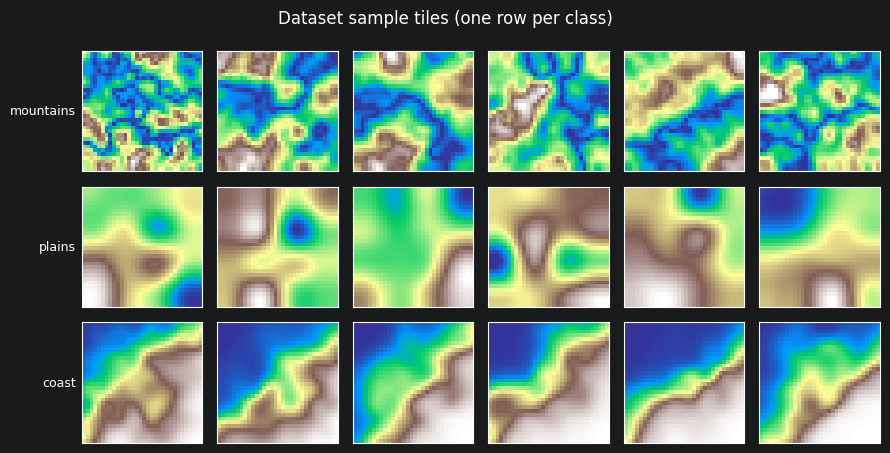

In [7]:
# Peek: a few tiles per class. The row label on the left names the class.
fig, ax = plt.subplots(3, 6, figsize=(9, 4.6))
for c in range(3):
    idx = (y == c).nonzero(as_tuple=True)[0][:6]                    # first 6 of this class
    for k, j in enumerate(idx):
        panel(ax[c, k], X[j, 0].cpu(), ylabel=CLASS_NAMES[c] if k == 0 else None)
plt.suptitle("Dataset sample tiles (one row per class)"); plt.tight_layout(); plt.show()

## Section 3. The forward process: adding noise on a schedule

The forward process turns an image `x0` into noise over `T` steps. It is a **Markov chain**: each step
depends only on the one before it, `x0 -> x1 -> x2 -> ... -> xT`, with no memory of anything earlier.
The physical picture is a drop of ink in water, spreading from a concentrated, structured state into a
uniform, structureless one. Destroying structure like this is easy. Running it *backwards*, from noise
back to a picture, is the part we have to learn.

The amount of noise added at each step is set by a **noise schedule** `beta[t]`. Rather than add noise
one step at a time, there is a famous **closed-form shortcut**: because a sum of Gaussians is itself a
Gaussian, we can jump straight to step `t` in one line.

Let `alpha[t] = 1 - beta[t]` and `alpha_bar[t] = product of alpha[0..t]`. Then

`x_t = sqrt(alpha_bar[t]) * x0 + sqrt(1 - alpha_bar[t]) * noise`,  where `noise ~ Normal(0, I)`.

So `alpha_bar[t]` is the fraction of the **original image** left at step `t`: it starts near 1 (all image)
and decays toward 0 (mostly noise). With a short schedule like ours (`T = 200`) it stops a little above 0,
which is fine because sampling always begins from pure noise anyway.

In [8]:
# Linear beta schedule (the DDPM default) and the quantities derived from it.
betas       = torch.linspace(1e-4, 0.02, T, device=device)   # small -> larger noise per step
alphas      = 1.0 - betas                                     # kept fraction per step
alpha_bar   = torch.cumprod(alphas, dim=0)                    # cumulative kept fraction (alpha_bar[t])
sqrt_ab     = alpha_bar.sqrt()                                # coefficient on x0
sqrt_1m_ab  = (1 - alpha_bar).sqrt()                          # coefficient on noise

def q_sample(x0, t, noise):
    # Closed-form: jump straight to step t (t is a [batch] LongTensor of step indices).
    return sqrt_ab[t][:, None, None, None] * x0 + sqrt_1m_ab[t][:, None, None, None] * noise

print("alpha_bar[0]  =", round(float(alpha_bar[0]), 4), "(almost all image)")
print("alpha_bar[-1] =", round(float(alpha_bar[-1]), 4), "(mostly noise)")

alpha_bar[0]  = 0.9999 (almost all image)
alpha_bar[-1] = 0.1322 (mostly noise)


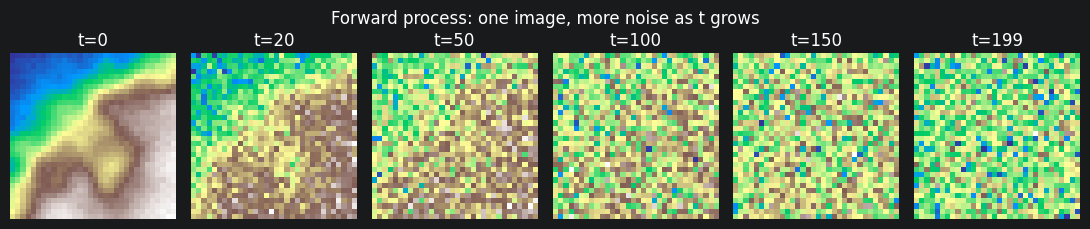

In [9]:
# Watch one tile get noisier as t increases (using the one-line shortcut, not a loop).
x0 = X[(y == 2).nonzero(as_tuple=True)[0][0]:(y == 2).nonzero(as_tuple=True)[0][0] + 1]  # a coast tile
steps_to_show = [0, 20, 50, 100, 150, 199]
fig, ax = plt.subplots(1, len(steps_to_show), figsize=(11, 2.3))
for k, ti in enumerate(steps_to_show):
    t = torch.tensor([ti], device=device)
    xt = q_sample(x0, t, torch.randn_like(x0))                 # noised image at step ti
    ax[k].imshow(xt[0, 0].cpu(), cmap="terrain"); ax[k].axis("off"); ax[k].set_title(f"t={ti}")
plt.suptitle("Forward process: one image, more noise as t grows"); plt.tight_layout(); plt.show()

### The shortcut, checked
Why trust the one-line formula? Because adding many small Gaussians is itself one Gaussian, noising **step
by step** and noising in a **single jump** land at the same noise level. Below we noise one tile both ways
to the same step and compare: the pictures look equally noisy and the mean and standard deviation match.
This is why we never loop the forward process in practice, we just use the closed form.

step by step to t=100:  mean -0.025  std 0.704
one-shot shortcut:           mean -0.031  std 0.702


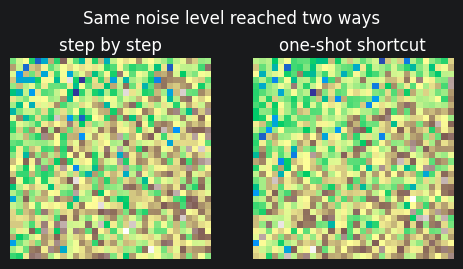

In [10]:
t_check = 100                                                  # the step we noise up to
# (a) Step by step: apply x_t = sqrt(alpha[t]) * x_{t-1} + sqrt(beta[t]) * noise, one step at a time.
x_step = x0.clone()
for ti in range(t_check):
    x_step = alphas[ti].sqrt() * x_step + betas[ti].sqrt() * torch.randn_like(x_step)
# (b) One jump with the closed-form shortcut (fresh noise, so pixels differ but the noise level matches).
x_jump = q_sample(x0, torch.tensor([t_check - 1], device=device), torch.randn_like(x0))

print(f"step by step to t={t_check}:  mean {float(x_step.mean()):+.3f}  std {float(x_step.std()):.3f}")
print(f"one-shot shortcut:           mean {float(x_jump.mean()):+.3f}  std {float(x_jump.std()):.3f}")
fig, ax = plt.subplots(1, 2, figsize=(5, 2.7))
ax[0].imshow(x_step[0, 0].cpu(), cmap="terrain"); ax[0].set_title("step by step"); ax[0].axis("off")
ax[1].imshow(x_jump[0, 0].cpu(), cmap="terrain"); ax[1].set_title("one-shot shortcut"); ax[1].axis("off")
plt.suptitle("Same noise level reached two ways"); plt.tight_layout(); plt.show()

### Comparing noise schedules (linear vs cosine)
The **schedule** decides *how fast* the image dissolves into noise. The linear schedule above destroys the
image fairly early; the **cosine** schedule keeps more signal for longer, which often helps quality. The
plot below shows `alpha_bar[t]` (fraction of image left) for both. This is the "noise scheduling
difference" in one picture.

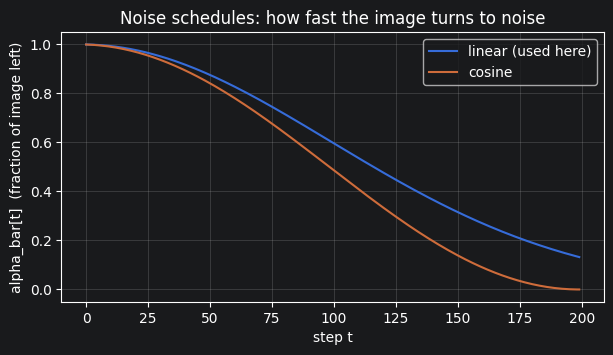

In [11]:
# Cosine schedule alpha_bar (Nichol and Dhariwal), for comparison with the linear one.
def cosine_alpha_bar(T, s=0.008):
    t = torch.linspace(0, T, T + 1)
    f = torch.cos(((t / T + s) / (1 + s)) * math.pi / 2) ** 2
    ab = f / f[0]
    return ab[1:].to(device)                                   # length T

ab_cos = cosine_alpha_bar(T)

plt.figure(figsize=(7, 3.5))
plt.plot(alpha_bar.cpu(), label="linear (used here)")
plt.plot(ab_cos.cpu(), label="cosine")
plt.xlabel("step t"); plt.ylabel("alpha_bar[t]  (fraction of image left)")
plt.title("Noise schedules: how fast the image turns to noise")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

## Section 4. DDPM: the denoising network

The learned part is a small **U-Net** that looks at a noised image `x_t` and the step number `t`, and
predicts the **noise** that was added. The step `t` enters through a **sinusoidal time embedding** (the
same trick used for positions in transformers), so one network can handle every noise level.

We show the architecture, then **load a pre-trained model** (or train it quickly if no weights are
saved). Training a diffusion model from scratch is slow, which is exactly why we hand you trained weights.

In [12]:
def time_embedding(t, dim):
    # Map integer step t -> a smooth vector of sines and cosines of different frequencies.
    half = dim // 2
    freqs = torch.exp(torch.arange(half, device=t.device) * -(math.log(10000) / (half - 1)))
    ang = t[:, None].float() * freqs[None]                     # [batch, half]
    return torch.cat([ang.sin(), ang.cos()], dim=-1)           # [batch, dim]

class ResBlock(nn.Module):
    # Two convs + GroupNorm + SiLU, with the time embedding added in, and a residual skip.
    def __init__(self, ci, co, td):
        super().__init__()
        self.c1 = nn.Conv2d(ci, co, 3, padding=1); self.c2 = nn.Conv2d(co, co, 3, padding=1)
        self.n1 = nn.GroupNorm(8, co); self.n2 = nn.GroupNorm(8, co)
        self.emb = nn.Linear(td, co)
        self.skip = nn.Conv2d(ci, co, 1) if ci != co else nn.Identity()
    def forward(self, x, e):
        h = F.silu(self.n1(self.c1(x)))                        # conv -> norm -> activation
        h = h + self.emb(e)[:, :, None, None]                  # inject time information
        h = F.silu(self.n2(self.c2(h)))
        return h + self.skip(x)                                # residual connection

class UNet(nn.Module):
    # Tiny U-Net: 3 downsampling blocks, a middle block, 3 upsampling blocks with skip connections.
    def __init__(self, ch=32, td=64):
        super().__init__()
        self.td = td
        self.tmlp = nn.Sequential(nn.Linear(td, td), nn.SiLU(), nn.Linear(td, td))
        self.d1 = ResBlock(1, ch, td); self.d2 = ResBlock(ch, ch * 2, td); self.d3 = ResBlock(ch * 2, ch * 4, td)
        self.mid = ResBlock(ch * 4, ch * 4, td)
        self.u3 = ResBlock(ch * 8, ch * 2, td); self.u2 = ResBlock(ch * 4, ch, td); self.u1 = ResBlock(ch * 2, ch, td)
        self.out = nn.Conv2d(ch, 1, 1); self.pool = nn.AvgPool2d(2)
    def up(self, x):
        return F.interpolate(x, scale_factor=2, mode="nearest")
    def forward(self, x, t):
        e = self.tmlp(time_embedding(t, self.td))              # step -> embedding vector
        h1 = self.d1(x, e)                                     # 32x32
        h2 = self.d2(self.pool(h1), e)                         # 16x16
        h3 = self.d3(self.pool(h2), e)                         # 8x8
        m  = self.mid(self.pool(h3), e)                        # 4x4
        u  = self.u3(torch.cat([self.up(m), h3], 1), e)        # 8x8  (skip from h3)
        u  = self.u2(torch.cat([self.up(u), h2], 1), e)        # 16x16 (skip from h2)
        u  = self.u1(torch.cat([self.up(u), h1], 1), e)        # 32x32 (skip from h1)
        return self.out(u)                                     # predicted noise, same shape as x

unet = UNet().to(device)
print("U-Net parameters:", sum(p.numel() for p in unet.parameters()))

U-Net parameters: 914529


In [13]:
# Train the DDPM (predict the noise) or load saved weights.
unet_loss = []                                                 # loss per epoch (for the curve)
_unet_path = os.path.join(MODELS_DIR, "unet.pt")
if TRAIN_FROM_SCRATCH or not os.path.exists(_unet_path):
    opt = torch.optim.Adam(unet.parameters(), lr=2e-4)
    Nx = X.shape[0]; t0 = time.time()
    for ep in range(EPOCHS_UNET):
        perm = torch.randperm(Nx, device=device); tot = 0.0
        for i in range(0, Nx, BATCH):
            x0 = X[perm[i:i + BATCH]]                           # a batch of clean images
            t = torch.randint(0, T, (x0.shape[0],), device=device)   # random steps
            noise = torch.randn_like(x0)                       # the noise we will try to predict
            pred = unet(q_sample(x0, t, noise), t)             # network sees the noised image + step
            loss = F.mse_loss(pred, noise)                     # match the true noise
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item() * len(x0)
        unet_loss.append(tot / Nx)
        if (ep + 1) % 10 == 0:
            print(f"epoch {ep+1:3d}/{EPOCHS_UNET}  loss {unet_loss[-1]:.4f}  ({(time.time()-t0)/(ep+1):.2f}s/ep)")
    save_model(unet, "unet.pt")
else:
    load_model(unet, "unet.pt")
unet.eval();

loaded models/unet.pt


In [14]:
# If we trained, show the loss curve (2D). It should fall then flatten.
if unet_loss:
    plt.figure(figsize=(6, 3)); plt.plot(unet_loss)
    plt.xlabel("epoch"); plt.ylabel("noise-prediction MSE"); plt.title("DDPM training loss")
    plt.grid(True, alpha=0.3); plt.show()
else:
    print("Loaded pre-trained weights - no fresh loss curve to plot.")

Loaded pre-trained weights - no fresh loss curve to plot.


### Sampling from the DDPM (ancestral sampling)
To generate an image: start from pure noise and, for `t = T-1 ... 0`, ask the network for the noise,
remove a bit of it, and (except at the last step) add a small amount of fresh noise back. This
"one step at a time, slightly random" recipe is **ancestral sampling** and uses all `T` steps.

**How to judge the output.** Generation invents *new* images, so there is no single "correct" answer to
compare each one against (unlike super-resolution, where every output has a true target). Instead we show
a row of **real tiles** next to the generated ones: good samples should share the same look and texture as
the real data, without copying any single tile.

DDPM sampling of 6 images (200 steps) took 2.10s


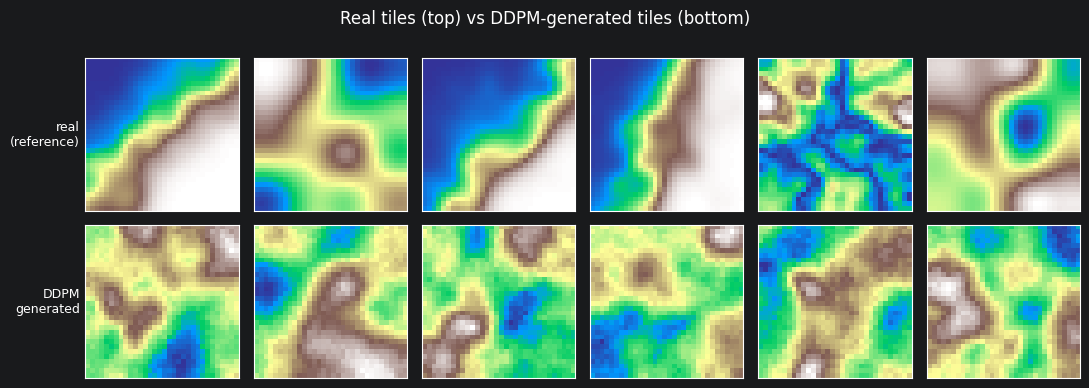

In [15]:
@torch.no_grad()
def ddpm_sample(n, keep_trajectory=False):
    # Generate n images by running the reverse process for all T steps.
    x = torch.randn(n, 1, IMG, IMG, device=device)             # start from pure noise
    traj = [x[0, 0].cpu().numpy()]                             # snapshots of image 0 (for a figure)
    for ti in reversed(range(T)):
        t = torch.full((n,), ti, device=device, dtype=torch.long)
        eps = unet(x, t)                                       # predicted noise
        a, ab, b = alphas[ti], alpha_bar[ti], betas[ti]
        mean = (x - b / (1 - ab).sqrt() * eps) / a.sqrt()      # posterior mean (the denoised guess)
        # The noise scale sigma_t has two standard choices: sqrt(beta_t), used here, or the posterior
        # sqrt(beta_tilde_t). Both are valid; sqrt(beta_t) is the simpler of the two.
        x = mean + (b.sqrt() * torch.randn_like(x) if ti > 0 else 0.0)   # add noise except last step
        if keep_trajectory and ti % (T // 8) == 0:
            traj.append(x[0, 0].cpu().numpy())
    x = x.clamp(-1, 1)
    return (x, traj) if keep_trajectory else x

t0 = time.time(); samples, traj = ddpm_sample(6, keep_trajectory=True)
print(f"DDPM sampling of 6 images ({T} steps) took {time.time()-t0:.2f}s")

# Top row = real tiles (the reference); bottom row = what the DDPM generated from noise.
ref = real_reference(6)
fig, ax = plt.subplots(2, 6, figsize=(11, 4.0))
for k in range(6):
    panel(ax[0, k], ref[k, 0].cpu(),     ylabel="real\n(reference)" if k == 0 else None)
    panel(ax[1, k], samples[k, 0].cpu(), ylabel="DDPM\ngenerated" if k == 0 else None)
plt.suptitle("Real tiles (top) vs DDPM-generated tiles (bottom)"); plt.tight_layout(); plt.show()

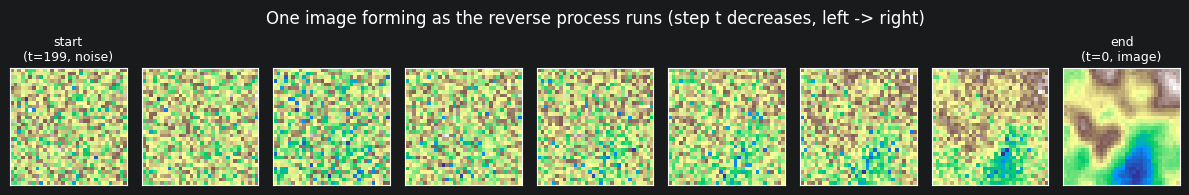

In [16]:
# The reverse trajectory: noise on the left, finished image on the right.
n_traj = len(traj)
fig, ax = plt.subplots(1, n_traj, figsize=(12, 2.1))
for k, im in enumerate(traj):
    lbl = "start\n(t=%d, noise)" % (T - 1) if k == 0 else ("end\n(t=0, image)" if k == n_traj - 1 else "")
    panel(ax[k], im, title=lbl)
plt.suptitle("One image forming as the reverse process runs (step t decreases, left -> right)")
plt.tight_layout(); plt.show()

## Section 5. DDIM: the same network, far fewer steps

**DDIM** samples from the **same trained U-Net** but in a **deterministic** way, and it can skip most of
the steps. At each chosen step it (1) predicts the noise, (2) estimates the clean image `x0` from it, and
(3) re-noises `x0` to the next (earlier) step, with **no** random term. Because there is no randomness,
the same starting noise always gives the same image, which is handy for interpolation later.

The practical win: DDPM might need 200 steps, DDIM often looks good in 10-50.

| | DDPM | DDIM |
|---|---|---|
| Reverse process | stochastic Markov chain | deterministic mapping |
| Same starting noise twice | different image each time | the same image every time |
| Sampling steps | all `T` | a subsequence (e.g. 10 or 50) |
| Data to latent | not invertible | invertible, which is what makes the interpolation in Section 6 possible |

Let us compare.

In [17]:
@torch.no_grad()
def ddim_sample(n, steps, x=None):
    # Deterministic sampling using a subset of the T steps. `steps` = how many we actually take.
    if x is None:
        x = torch.randn(n, 1, IMG, IMG, device=device)         # shared starting noise (unless given)
    seq = list(range(0, T, max(1, T // steps)))                # evenly spaced step indices
    for j in reversed(range(len(seq))):
        ti = seq[j]; tp = seq[j - 1] if j > 0 else 0           # current step and the previous (earlier) one
        t = torch.full((n,), ti, device=device, dtype=torch.long)
        eps = unet(x, t)                                       # predicted noise
        ab, ab_p = alpha_bar[ti], alpha_bar[tp]
        x0 = (x - (1 - ab).sqrt() * eps) / ab.sqrt()           # estimate the clean image
        x = ab_p.sqrt() * x0 + (1 - ab_p).sqrt() * eps         # deterministic step to tp (no added noise)
    return x.clamp(-1, 1)

# Same starting noise for a fair comparison.
z0 = torch.randn(6, 1, IMG, IMG, device=device)
timings = {}
t0 = time.time(); ddpm_imgs = ddpm_sample(6); timings["DDPM (200)"] = time.time() - t0
outs = {"DDPM (200 steps)": ddpm_imgs}
for s in [10, 50]:
    t0 = time.time(); outs[f"DDIM ({s} steps)"] = ddim_sample(6, s, x=z0.clone()); timings[f"DDIM ({s})"] = time.time() - t0
for k, v in timings.items():
    print(f"{k:12s} {v:.2f}s")

DDPM (200)   1.11s
DDIM (10)    0.04s
DDIM (50)    0.23s


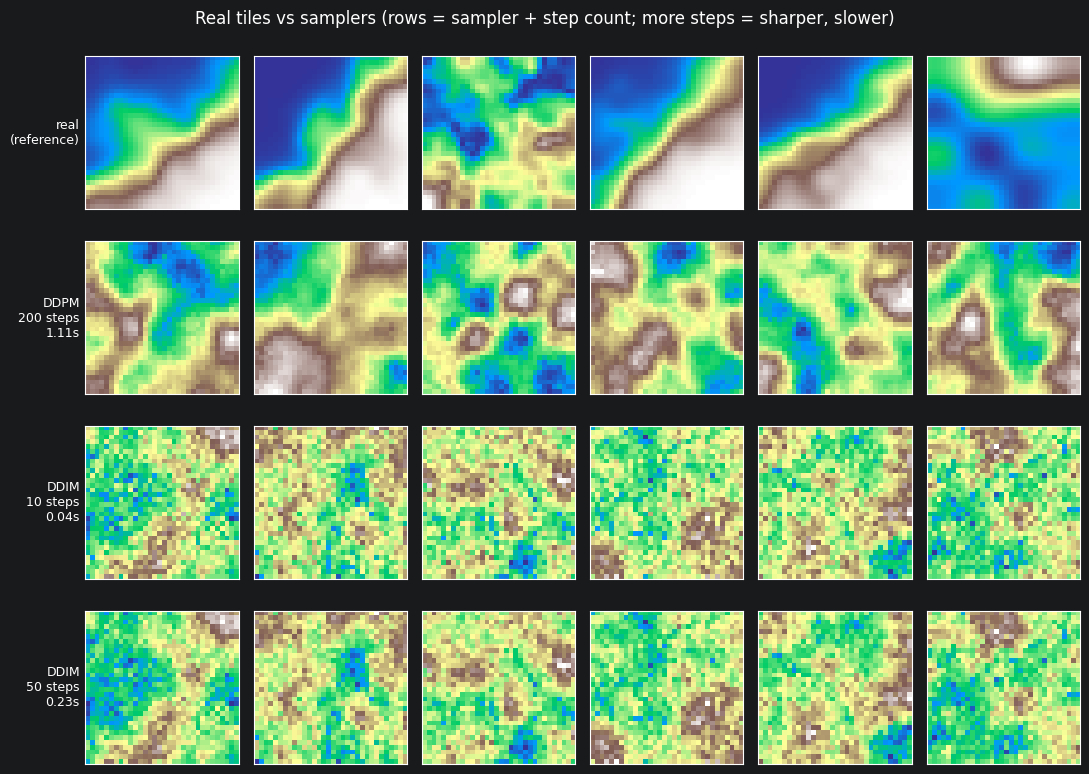

In [18]:
# Compare the samplers. Top row = real tiles (reference). Each row below is one sampler,
# labelled on the left with its step count and timing. Fewer steps = faster but coarser.
label_map = {"DDPM (200 steps)": f"DDPM\n200 steps\n{timings['DDPM (200)']:.2f}s",
             "DDIM (10 steps)":  f"DDIM\n10 steps\n{timings['DDIM (10)']:.2f}s",
             "DDIM (50 steps)":  f"DDIM\n50 steps\n{timings['DDIM (50)']:.2f}s"}
rows = [("real\n(reference)", real_reference(6))] + [(label_map[name], imgs) for name, imgs in outs.items()]
fig, ax = plt.subplots(len(rows), 6, figsize=(11, 2.0 * len(rows)))
for r, (name, imgs) in enumerate(rows):
    for k in range(6):
        panel(ax[r, k], imgs[k, 0].cpu(), ylabel=name if k == 0 else None)
plt.suptitle("Real tiles vs samplers (rows = sampler + step count; more steps = sharper, slower)")
plt.tight_layout(); plt.show()

## Section 6. Fewer steps = fuzzier; and latent interpolation

Two things to see here:

1. **Steps vs fuzziness.** Run DDIM from the **same** starting noise with 2, 5, 10, then 50 steps. With
   very few steps the image is coarse and fuzzy; more steps refine it. This is the speed/quality dial you
   will study in Part 2.
2. **Latent interpolation.** Because DDIM is deterministic, walking in a straight line between two noise
   vectors produces a **smooth morph** between the two images they generate.

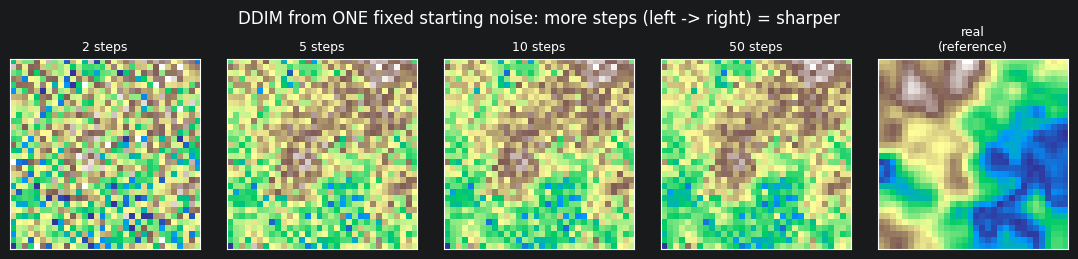

In [19]:
# 1) Same starting noise, increasing step counts. The last panel is a real tile for reference.
z1 = torch.randn(1, 1, IMG, IMG, device=device)
counts = [2, 5, 10, 50]
fig, ax = plt.subplots(1, len(counts) + 1, figsize=(11, 2.6))
for k, s in enumerate(counts):
    img = ddim_sample(1, s, x=z1.clone())
    panel(ax[k], img[0, 0].cpu(), title=f"{s} steps")
panel(ax[-1], real_reference(1)[0, 0].cpu(), title="real\n(reference)")
plt.suptitle("DDIM from ONE fixed starting noise: more steps (left -> right) = sharper")
plt.tight_layout(); plt.show()

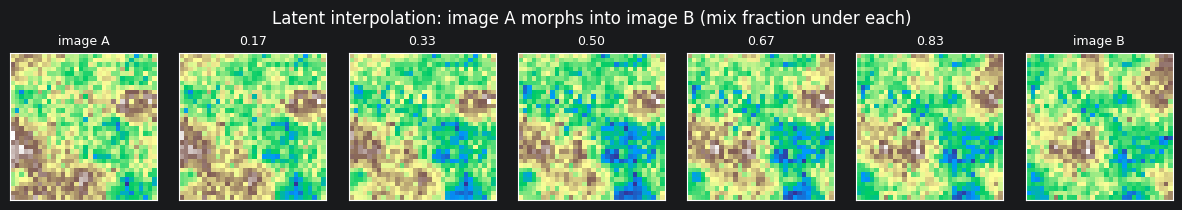

In [20]:
# 2) Latent interpolation between two starting noises (spherical interpolation looks best).
def slerp(a, b, frac):
    # Spherical interpolation between two noise tensors (keeps the vector length sensible).
    fa = a.flatten(); fb = b.flatten()
    omega = torch.acos((fa @ fb) / (fa.norm() * fb.norm() + 1e-8)).clamp(1e-4, math.pi - 1e-4)
    out = (torch.sin((1 - frac) * omega) * fa + torch.sin(frac * omega) * fb) / torch.sin(omega)
    return out.view_as(a)

zA = torch.randn(1, 1, IMG, IMG, device=device)
zB = torch.randn(1, 1, IMG, IMG, device=device)
fracs = np.linspace(0, 1, 7)
fig, ax = plt.subplots(1, len(fracs), figsize=(12, 2.1))
for k, fr in enumerate(fracs):
    img = ddim_sample(1, 30, x=slerp(zA, zB, float(fr)))
    lbl = "image A" if k == 0 else ("image B" if k == len(fracs) - 1 else f"{fr:.2f}")
    panel(ax[k], img[0, 0].cpu(), title=lbl)
plt.suptitle("Latent interpolation: image A morphs into image B (mix fraction under each)")
plt.tight_layout(); plt.show()

## Section 7. Score matching: the noise prediction is a gradient

There is another way to look at all of this. The **score** of a distribution is the gradient of its log
density, `score(x, t) = grad_x log p_t(x)`: at any point it **points toward where data is more likely**.
It is a compass, not a destination, so generating a sample means **following** it rather than jumping
straight to it.

### From a discrete chain to a continuous process
Push the number of noising steps to infinity and the DDPM forward chain becomes a continuous **stochastic
differential equation (SDE)**:

`dx = f(x, t) dt + g(t) dw`   (forward: data -> noise)

with `f` and `g` fixed drift and diffusion coefficients and `w` a Brownian motion. Reversing time gives a
**reverse SDE** that turns noise back into data, and it needs exactly one extra ingredient: the score.

`dx = [f(x, t) - g(t)^2 * score(x, t)] dt + g(t) dw̄`   (reverse: noise -> data, stochastic)

There is also a **deterministic** counterpart with the same marginal distributions at every `t`, the
**probability flow ODE (PF-ODE)**:

`dx = [f(x, t) - (1/2) g(t)^2 * score(x, t)] dt`   (reverse: noise -> data, deterministic)

Everything in both equations is known except one thing: the score. That is the whole rest of this
section.

### Two ways to discretise it
With a small step `dt > 0`, each equation above becomes an update rule:

- **SDE, Euler-Maruyama** (stochastic): `x -= dt * [f - g^2 * score] ; x += g * sqrt(dt) * z`
- **PF-ODE, Euler** (deterministic): `x -= dt * [f - 0.5 * g^2 * score]`   (no noise term at all)

This is exactly the DDPM-against-DDIM contrast from Sections 4 and 5, one level more abstract: a
stochastic solver and a deterministic solver, built from the **same** score, converging to the **same**
distribution. We will build both.

### Where DDPM's noise prediction fits in
Recall the forward process: `x_t = sqrt(alpha_bar[t]) * x0 + sqrt(1 - alpha_bar[t]) * noise`. That makes
`x_t` a Gaussian centred on `sqrt(alpha_bar[t]) * x0`, and the **score of a Gaussian is just minus the
standardised noise**:

`score(x_t, t) = grad log p(x_t | x0) = -noise / sqrt(1 - alpha_bar[t])`

The network was trained to predict exactly that `noise`. So its output, rescaled, **is** the score:

`score_theta(x_t, t) = -eps_theta(x_t, t) / sqrt(1 - alpha_bar[t])`

DDPM was learning the score the entire time, without ever being told to. We will check this identity on
the real image network at the end of this section. First, a 2D dataset small enough to actually *see*
the score as a vector field: an **island coastline**, points scattered around a wobbly ring.

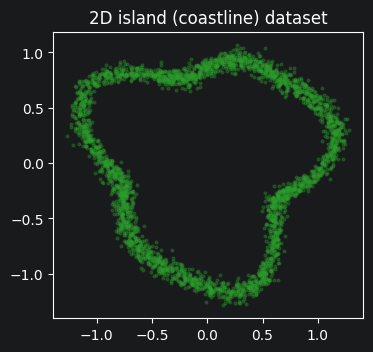

In [21]:
# A 2D "island" point cloud: a wobbly ring (coastline).
def make_island(n, rng):
    th = rng.uniform(0, 2 * np.pi, n)                          # angle around the ring
    r = 1.0 + 0.18 * np.sin(3 * th) + 0.10 * np.sin(5 * th + 1) + 0.05 * rng.standard_normal(n)  # wobbly radius
    return np.stack([r * np.cos(th), r * np.sin(th)], 1).astype(np.float32)

island = torch.tensor(make_island(3000, np.random.default_rng(1))).to(device)
plt.figure(figsize=(4, 4)); plt.scatter(island[:, 0].cpu(), island[:, 1].cpu(), s=4, alpha=0.3, color="tab:green")
plt.title("2D island (coastline) dataset"); plt.gca().set_aspect("equal"); plt.show()

In [22]:
# A small MLP score network, trained by DENOISING SCORE MATCHING at a fixed noise level sigma.
# This is the same identity just derived: perturb a point by Gaussian noise, and the true score of
# the perturbed point is -noise/sigma. We train the network to predict that directly.
SIGMA = 0.20
class ScoreNet(nn.Module):
    def __init__(self, h=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(2, h), nn.SiLU(), nn.Linear(h, h), nn.SiLU(),
                                 nn.Linear(h, h), nn.SiLU(), nn.Linear(h, 2))
    def forward(self, x):
        return self.net(x)

score = ScoreNet().to(device)
score_loss = []
_score_path = os.path.join(MODELS_DIR, "score.pt")
if TRAIN_FROM_SCRATCH or not os.path.exists(_score_path):
    opt = torch.optim.Adam(score.parameters(), lr=1e-3)
    Ni = island.shape[0]
    for ep in range(EPOCHS_SCORE):
        perm = torch.randperm(Ni, device=device); tot = 0.0
        for i in range(0, Ni, 256):
            x = island[perm[i:i + 256]]
            eps = torch.randn_like(x); xt = x + SIGMA * eps    # perturb the point
            target = -eps / SIGMA                              # the true score of the noised point
            loss = F.mse_loss(score(xt), target)               # denoising score matching
            opt.zero_grad(); loss.backward(); opt.step(); tot += loss.item() * len(x)
        score_loss.append(tot / Ni)
    save_model(score, "score.pt")
else:
    load_model(score, "score.pt")
score.eval();

loaded models/score.pt


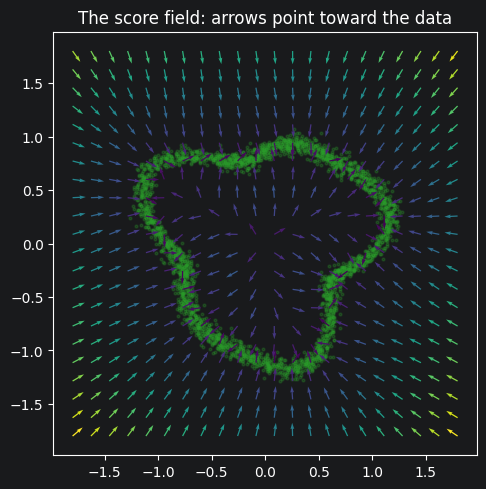

In [23]:
# Draw the learned score as a vector field (arrows point toward the coastline).
gx = np.linspace(-1.8, 1.8, 22); gy = np.linspace(-1.8, 1.8, 22)
GX, GY = np.meshgrid(gx, gy)
grid = torch.tensor(np.stack([GX.ravel(), GY.ravel()], 1), dtype=torch.float32, device=device)
with torch.no_grad():
    s = score(grid).cpu().numpy()
U = s[:, 0].reshape(GX.shape); V = s[:, 1].reshape(GX.shape)
mag = np.hypot(U, V); Un, Vn = U / (mag + 1e-6), V / (mag + 1e-6)

plt.figure(figsize=(5.5, 5.5))
plt.scatter(island[:, 0].cpu(), island[:, 1].cpu(), s=4, alpha=0.25, color="tab:green")
plt.quiver(GX, GY, Un, Vn, mag, cmap="viridis", scale=32, width=0.003)
plt.title("The score field: arrows point toward the data"); plt.gca().set_aspect("equal"); plt.show()

In [24]:
# Optional interactive 3D: the score magnitude as a surface (a "ridge" over the coastline).
if HAVE_PLOTLY:
    fig = go.Figure(data=[go.Surface(x=GX, y=GY, z=mag, colorscale="Viridis")])
    fig.update_layout(title="Score magnitude over the plane (rotate me)", height=450,
                      scene=dict(xaxis_title="x", yaxis_title="y", zaxis_title="|score|"))
    fig.show()
else:
    print("Plotly not available - the 2D quiver above is enough.")

### Two solvers, one score

Both update rules from the markdown above, specialised to our toy: since the score net was trained at
one fixed noise level rather than a full annealed schedule, the simplest honest choice is `f = 0` and
`g = 1` (a stationary field, no separate drift or time-varying noise scale). Substituting that in:

- **SDE (Euler-Maruyama):** `x += dt * score(x) + sqrt(dt) * z`
- **PF-ODE (Euler):** `x += 0.5 * dt * score(x)`   (identical, minus the noise, minus the factor of 2)

Same score network, same step size, two different walks.

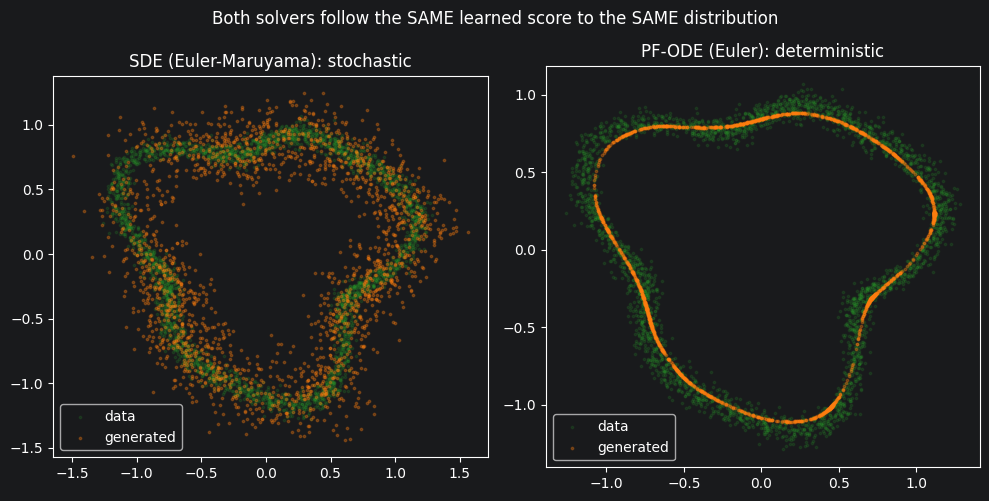

     SDE sample radius: mean 0.98, std 0.20  (data: mean 1.00, std 0.15)
  PF-ODE sample radius: mean 0.97, std 0.13  (data: mean 1.00, std 0.15)


In [25]:
@torch.no_grad()
def euler_maruyama_sde(n, steps=300, dt=2e-3):
    # Discretised REVERSE SDE (f=0, g=1): stochastic, injects fresh noise every step.
    x = torch.randn(n, 2, device=device) * 1.2                 # start scattered, like pure noise
    for _ in range(steps):
        x = x + dt * score(x) + (dt ** 0.5) * torch.randn_like(x)   # follow the score + noise
    return x.cpu().numpy()

@torch.no_grad()
def euler_pf_ode(n, steps=300, dt=2e-3):
    # Discretised PF-ODE (f=0, g=1): deterministic, no noise term at all.
    x = torch.randn(n, 2, device=device) * 1.2                 # same starting distribution
    for _ in range(steps):
        x = x + 0.5 * dt * score(x)                             # follow the score, nothing else
    return x.cpu().numpy()

samp_sde = euler_maruyama_sde(2000)
samp_ode = euler_pf_ode(2000)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
for a, samp, title in [(ax[0], samp_sde, "SDE (Euler-Maruyama): stochastic"),
                       (ax[1], samp_ode, "PF-ODE (Euler): deterministic")]:
    a.scatter(island[:, 0].cpu(), island[:, 1].cpu(), s=3, alpha=0.15, color="tab:green", label="data")
    a.scatter(samp[:, 0], samp[:, 1], s=3, alpha=0.3, color="tab:orange", label="generated")
    a.set_title(title); a.legend(); a.set_aspect("equal")
plt.suptitle("Both solvers follow the SAME learned score to the SAME distribution"); plt.tight_layout(); plt.show()

for name, samp in [("SDE", samp_sde), ("PF-ODE", samp_ode)]:
    r = np.hypot(*samp.T)
    print(f"{name:>8} sample radius: mean {r.mean():.2f}, std {r.std():.2f}  (data: mean 1.00, std "
          f"{float(np.hypot(*island.cpu().numpy().T).std()):.2f})")

In [26]:
# The DDPM vs DDIM duality, one more time: same start, does the SDE solver vary while the ODE solver
# repeats? Run each twice from a FIXED starting point and compare.
torch.manual_seed(0)
x0_fixed = (torch.randn(3, 2, device=device) * 1.2)

@torch.no_grad()
def _run_from(x0, solver, **kw):
    x = x0.clone()
    steps = kw.get("steps", 300); dt = kw.get("dt", 2e-3)
    for _ in range(steps):
        if solver == "sde": x = x + dt * score(x) + (dt ** 0.5) * torch.randn_like(x)
        else:               x = x + 0.5 * dt * score(x)
    return x.cpu().numpy()

print("PF-ODE, same start, two runs (should be IDENTICAL, no randomness in the walk):")
print(" run 1:", _run_from(x0_fixed, "ode").round(3).tolist())
print(" run 2:", _run_from(x0_fixed, "ode").round(3).tolist())
print("\nSDE, same start, two runs (should DIFFER, fresh noise injected every step):")
print(" run 1:", _run_from(x0_fixed, "sde").round(3).tolist())
print(" run 2:", _run_from(x0_fixed, "sde").round(3).tolist())

PF-ODE, same start, two runs (should be IDENTICAL, no randomness in the walk):
 run 1: [[-0.210999995470047, -1.00600004196167], [0.4449999928474426, -1.0190000534057617], [0.44600000977516174, -1.0169999599456787]]
 run 2: [[-0.210999995470047, -1.00600004196167], [0.4449999928474426, -1.0190000534057617], [0.44600000977516174, -1.0169999599456787]]

SDE, same start, two runs (should DIFFER, fresh noise injected every step):
 run 1: [[-0.7289999723434448, -0.546999990940094], [0.6650000214576721, -0.6790000200271606], [0.5220000147819519, -1.2139999866485596]]
 run 2: [[-0.4519999921321869, -0.5870000123977661], [0.5, -0.9120000004768372], [-0.2800000011920929, -0.6759999990463257]]


### Checking the identity on the real image model

That noise-prediction-is-a-score identity was not just for the 2D toy. It holds for the trained image
`unet` from Section 4 too: take a real tile, noise it to some step `t`, ask the network for its
predicted noise, and rescale. No new training, no new model, just the formula from the markdown above
applied to weights already on disk.

In [27]:
real_tile = X[torch.randint(0, X.shape[0], (1,))]              # one real terrain tile
t_probe = torch.tensor([80], device=device)                     # a step partway through the schedule
noise_true = torch.randn_like(real_tile)
xt = q_sample(real_tile, t_probe, noise_true)                   # noise it, exactly as in Section 4

with torch.no_grad():
    eps_pred = unet(xt, t_probe)                                 # the network's noise prediction
score_from_unet = -eps_pred / sqrt_1m_ab[t_probe][:, None, None, None]   # the formula from above

print(f"at t={int(t_probe.item())}: sqrt(1 - alpha_bar[t]) = {float(sqrt_1m_ab[t_probe]):.4f}")
print(f"predicted-noise norm : {eps_pred.norm().item():.3f}")
print(f"implied score norm   : {score_from_unet.norm().item():.3f}  "
      f"(= noise norm / {float(sqrt_1m_ab[t_probe]):.4f})")
print("\nThe image network was never trained to predict a score, only noise. This rescaling is exact,")
print("not approximate: it is the same algebra we used for the 2D toy, just in 32x32 dimensions.")

at t=80: sqrt(1 - alpha_bar[t]) = 0.5322
predicted-noise norm : 32.061
implied score norm   : 60.242  (= noise norm / 0.5322)

The image network was never trained to predict a score, only noise. This rescaling is exact,
not approximate: it is the same algebra we used for the 2D toy, just in 32x32 dimensions.


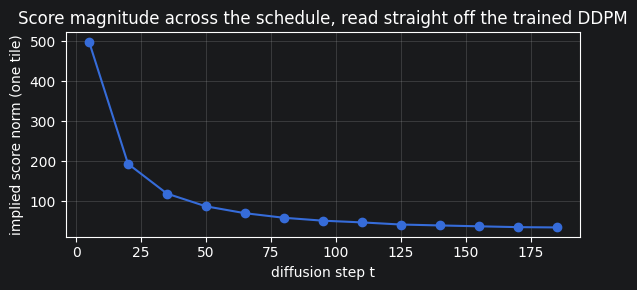

In [28]:
# The identity holds at every step, not just t=80. Read it off across the whole schedule.
ts_probe = torch.arange(5, T, 15, device=device)
score_norms = []
with torch.no_grad():
    for tt in ts_probe:
        tb = tt.unsqueeze(0)
        xt_p = q_sample(real_tile, tb, torch.randn_like(real_tile))
        eps_p = unet(xt_p, tb)
        score_norms.append((-eps_p / sqrt_1m_ab[tb][:, None, None, None]).norm().item())

plt.figure(figsize=(6, 3))
plt.plot(ts_probe.cpu(), score_norms, "o-")
plt.xlabel("diffusion step t"); plt.ylabel("implied score norm (one tile)")
plt.title("Score magnitude across the schedule, read straight off the trained DDPM")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## Section 8. Recap

You have now seen the whole diffusion family on small, watchable data:

- the **forward process** and the closed-form noising shortcut, and how the **schedule** controls it,
- a **DDPM**: a U-Net trained to predict noise, sampled step by step (stochastic, many steps),
- a **DDIM**: the **same** network sampled deterministically in far fewer steps, with smooth latent
  interpolation as a bonus,
- **score matching**: the score as a **vector field**, sampled with two solvers built from the same
  score, a stochastic **SDE** and a deterministic **PF-ODE**, and the fact that the DDPM noise
  prediction *is* a scaled score, checked directly on the trained image network.

The honest limits: these are tiny models on tiny images, so samples are rough. Real systems (Stable
Diffusion and friends) use the exact same ideas with far more capacity, better schedules, and text
conditioning.

The models you used are saved in `models/` (`unet.pt`, `score.pt`), so you can reload them instantly.
On to Part 2.

---
# Part 2 - Unguided exercise (about 60 to 90 minutes)

This is an **unguided exercise**, longer and harder than the guided part. There are hints but **no worked
solution**. It builds directly on Part 1, so run Part 1 first: you will reuse `unet`, `ddpm_sample`,
`ddim_sample`, `alpha_bar`, `alphas`, `betas`, `T`, `IMG`, `X` (the real tiles), `q_sample`,
`cosine_alpha_bar`, the `panel` helper, and `device`.

There are **four tasks**. They get harder as you go: the first is a warm-up, the last two ask you to
extend the sampler and to analyse the model's behaviour, not just run it.

## Task 1, speed vs quality (about 15 min)
DDIM trades sampling **speed** for **quality** through the number of steps. For step counts
`[2, 5, 10, 20, 50]`, sample a batch of 16 with `ddim_sample` and time each; also time one full
`ddpm_sample`. Then, from a **fixed** starting noise, use a quality proxy: the mean absolute difference
between the `s`-step image and the `50`-step image (treat 50 steps as the reference). Plot time vs steps
and proxy vs steps, and say where the "knee" is.

*Hints:* time with `t0 = time.time(); ...; time.time() - t0`. Reuse one noise
`z = torch.randn(16, 1, IMG, IMG, device=device)` and pass `x=z.clone()` so every run starts alike.
Mean abs diff: `(a - b).abs().mean().item()`.

## Task 2, build a stochastic sampler (eta-DDIM) (about 25 min)
Plain DDIM (Part 1) is fully deterministic. The general DDIM update adds a **stochasticity knob** `eta`:
`eta = 0` is the deterministic DDIM you already have, and `eta = 1` behaves like the stochastic DDPM.
Write `ddim_eta_sample(n, steps, eta, x=None)` using, at each step from `t` to the earlier step `p`:

```
x0     = (x - sqrt(1 - ab_t) * eps) / sqrt(ab_t)           # predicted clean image
sigma  = eta * sqrt((1 - ab_p) / (1 - ab_t)) * sqrt(1 - ab_t / ab_p)
x_prev = sqrt(ab_p) * x0 + sqrt(max(0, 1 - ab_p - sigma^2)) * eps + sigma * randn_like(x)
```

where `ab_t = alpha_bar[t]`, `ab_p = alpha_bar[p]`. Then show two things: (a) with `eta = 0`, sampling
**twice from the same noise** gives identical images (determinism); with `eta = 1` the two differ. (b)
Generate a batch at `eta` in `{0.0, 0.5, 1.0}` and report **diversity** as the mean pairwise distance
between samples. Which eta is most diverse, and why?

*Hint:* copy the `ddim_sample` loop from Part 1 and add the `sigma` term. Mean pairwise distance:
flatten to `[n, -1]`, then `torch.cdist(f, f)` and average the off-diagonal.

## Task 3, is the model memorising the training set? (about 20 min)
A good generator invents new tiles rather than copying the training data. Check this. Generate 32 tiles,
and for each find the **nearest real tile** (smallest pixel distance to any tile in `X`). Compare the
distribution of those nearest-neighbour distances to a **baseline**: the nearest-neighbour distances of
*real* tiles to *other* real tiles. Plot both as histograms and decide: is the model copying, or
generating genuinely new tiles?

*Hints:* split `X` into a reference half and a query half so a real tile never matches itself. Flatten and
use `torch.cdist(gen_flat, ref_flat).min(dim=1).values`. If the generated distances sit in the same range
as the real-to-real distances, the model is not memorising.

## Task 4, does the noise schedule matter? (about 15 min)
Part 1 trained on a **linear** schedule and showed a **cosine** one only as a curve. Now compare them on
images. Take one real tile and, using the **same** noise sample, noise it to the same steps
`[20, 50, 100, 150]` under both `alpha_bar` (linear) and `cosine_alpha_bar(T)` (cosine). Show the two rows
side by side. Which schedule keeps the tile recognisable for longer, and how does that match the curve you
saw in Section 3? (Two or three sentences.)

*Hint:* the closed form is `sqrt(ab[t]) * x0 + sqrt(1 - ab[t]) * noise`; use the **same** `noise` for both
schedules so the only difference is `ab`.

### What to submit
Your filled-in cells (runnable top to bottom), the plots from each task, and short written answers to the
questions in Tasks 2, 3, and 4.

### Task 1 (your code below)

In [29]:
# TODO Task 1: time ddim_sample for steps [2,5,10,20,50] and one ddpm_sample; quality proxy vs 50-step ref; plots + knee.

### Task 2 (your code below)

In [30]:
# TODO Task 2: write ddim_eta_sample(n, steps, eta, x=None); show eta=0 deterministic vs eta=1 random; diversity at eta in {0,0.5,1}.

### Task 3 (your code below)

In [31]:
# TODO Task 3: nearest-real-tile distance for generated vs real-to-real baseline; two histograms; memorising or not?

### Task 4 (your code below)

In [32]:
# TODO Task 4: noise one tile under linear vs cosine alpha_bar at t=[20,50,100,150] with the SAME noise; compare + explain.